# Análise Exploratória de Dados

## Enunciado

Nesta tarefa, você fará uma análise exploratória de dados (EDA) usando os dados apresentados em sala de aula. Esse processo ajudará você a entender os padrões e insights em conjunto de dados. Abaixo estão instruções detalhadas sobre como concluir esta tarefa de forma eficaz.

Guilherme Kastner

## Etapa 0

### Importação de bibliotecas

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#importação do profiler
from ydata_profiling import ProfileReport


### Leitura de arquivos

In [18]:
data_countries = "https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Dados/data_countries_clean.csv" #caminho do arquivo

df_data_countries = pd.read_csv(data_countries)
# exclusão da última coluna, que é a taxa de suicídio
df_data_countries.drop(df_data_countries.columns[-1], axis=1, inplace=True)
print(df_data_countries.head())  # Exibe as primeiras 5 linhas do DataFrame

       country  year  basic_sanitation_access_percent  \
0  Afghanistan  1999                             23.5   
1  Afghanistan  2000                             23.5   
2  Afghanistan  2001                             24.6   
3  Afghanistan  2002                             25.8   
4  Afghanistan  2003                             26.9   

   child_mortality_0_5_year_olds_dying_per_1000_born  \
0                                              129.0   
1                                              125.0   
2                                              121.0   
3                                              117.0   
4                                              113.0   

   children_per_woman_total_fertility  co2_emissions_tonnes_per_person  \
0                                7.49                           0.0370   
1                                7.39                           0.0376   
2                                7.27                           0.0471   
3                       

In [19]:
# salvar os dados em um arquivo excel para um teste
# df_data_countries.to_excel("data_countries.xlsx")
# print("Arquivo Excel criado com sucesso!")

In [20]:
# Análise de quantidade de dados de linhas e colunas
print(f"Quantidade de linhas: {df_data_countries.shape[0]}")
print(f"Quantidade de colunas: {df_data_countries.shape[1]}")

Quantidade de linhas: 3613
Quantidade de colunas: 11


In [21]:
# Análise da quantidade de países únicos
print(f"Quantidade de países únicos: {df_data_countries['country'].nunique()}")
print()

#lista de todos os países do a partir do df_data_countries
lista_paises = df_data_countries['country'].unique()
# Exibição da lista de países únicos
print("Lista de países únicos:")
print(lista_paises)

# salvar a lista de países em um arquivo texto
# with open("lista_paises.txt", "w") as f:
#     for pais in lista_paises:
#         f.write(f"{pais}\n")
# print("Lista de países salva em lista_paises.txt com sucesso!")



Quantidade de países únicos: 178

Lista de países únicos:
['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei' 'Bulgaria'
 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada' 'Cape Verde'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia' 'Comoros'
 'Congo, Dem. Rep.' 'Congo, Rep.' 'Costa Rica' "Cote d'Ivoire" 'Croatia'
 'Cuba' 'Cyprus' 'Czech Republic' 'Denmark' 'Djibouti'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea'
 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Fiji' 'Finland' 'France'
 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece' 'Guatemala'
 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti' 'Honduras' 'Hong Kong, China'
 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran' 'Iraq' 'Ireland' 'Israel'
 'Italy' 'Jamaica' 'Japan' 'Jordan' 'Kazakhsta

In [22]:
# lista criada manualmente com o nome dos países do Mercoul
lista_mercosul = [
    "Argentina",
    "Bolivia",
    "Brazil",
    "Paraguay",
    "Uruguay",
    "Venezuela"
]
# Filtrando os dados para os países do Mercosul
df_mercosul = df_data_countries[df_data_countries['country'].isin(lista_mercosul)]
# Exibição da quantidade de linhas restantes no novo dataframe
print(f"Quantidade de linhas restantes no DataFrame filtrado: {df_mercosul.shape[0]}")


Quantidade de linhas restantes no DataFrame filtrado: 111


In [23]:
# Utilização do profiler para gerar um relatório de análise exploratória do mercosul
profile = ProfileReport(df_mercosul, title="Mercosul Data Profiling Report")
profile.to_file("mercosul_data_profiling_report.html")
print("Relatório de análise exploratória gerado com sucesso!")

e:\UFPR\PythonProjectPPGold\venv\lib\site-packages\ydata_profiling\utils\dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 32.85it/s]

Relatório de análise exploratória gerado com sucesso!


In [24]:
# Exibição do dataframe completo
print(df_mercosul)

        country  year  basic_sanitation_access_percent  \
80    Argentina  1990                              NaN   
81    Argentina  1991                              NaN   
82    Argentina  1992                              NaN   
83    Argentina  1993                              NaN   
84    Argentina  1994                              NaN   
...         ...   ...                              ...   
3536  Venezuela  2012                             93.9   
3537  Venezuela  2013                             93.9   
3538  Venezuela  2014                             93.9   
3539  Venezuela  2015                             93.9   
3540  Venezuela  2016                             93.9   

      child_mortality_0_5_year_olds_dying_per_1000_born  \
80                                                 28.1   
81                                                 27.3   
82                                                 26.3   
83                                                 25.2   
84      

In [25]:
# Análise de tipo de dado para cada coluna do dataframe
print(df_mercosul.dtypes)

country                                                   object
year                                                       int64
basic_sanitation_access_percent                          float64
child_mortality_0_5_year_olds_dying_per_1000_born        float64
children_per_woman_total_fertility                       float64
co2_emissions_tonnes_per_person                          float64
employment_rate_percent                                  float64
hdi                                                      float64
income_per_person_gdppercapita_ppp_inflation_adjusted      int64
life_expectancy                                          float64
population_total                                           int64
dtype: object


In [26]:
# Análise de valores nulos
print(df_mercosul.isnull().sum())

country                                                  0
year                                                     0
basic_sanitation_access_percent                          9
child_mortality_0_5_year_olds_dying_per_1000_born        0
children_per_woman_total_fertility                       0
co2_emissions_tonnes_per_person                          0
employment_rate_percent                                  0
hdi                                                      0
income_per_person_gdppercapita_ppp_inflation_adjusted    0
life_expectancy                                          0
population_total                                         0
dtype: int64


In [27]:
# Análise de percentual de valores NaN em basic_sanitation_access_percent
percent_nan = df_mercosul['basic_sanitation_access_percent'].isnull().mean() * 100
print(f"Percentual de valores NaN em basic_sanitation_access_percent: {percent_nan:.2f}%")

Percentual de valores NaN em basic_sanitation_access_percent: 8.11%


In [28]:
# Análise de percentual de valores de cada país onde os dados de basic_sanitation_access_percent são NaN
# mostrando os números preenchidos e não preenchidos por país
print("Percentual de valores NaN por país:")
print(df_mercosul.groupby('country')['basic_sanitation_access_percent'].apply(lambda x: x.isnull().mean() * 100))


Percentual de valores NaN por país:
country
Argentina    26.086957
Bolivia       0.000000
Brazil        0.000000
Paraguay      0.000000
Uruguay       0.000000
Venezuela    18.750000
Name: basic_sanitation_access_percent, dtype: float64


In [29]:
# Geração do arquivo excel para o df_mercosul
df_mercosul.to_excel("df_mercosul.xlsx", index=False)


## Etapa 2: Análise de dados

### Análise exploratória de dados:



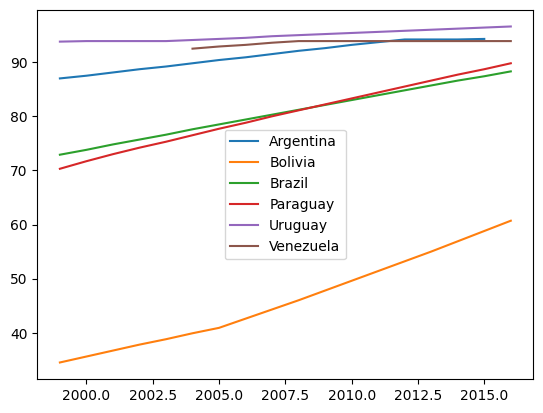

In [31]:
# Análise da evolução do acesso básico a saneamento no Mercosul
%matplotlib inline

df = df_mercosul.dropna(subset=['basic_sanitation_access_percent'])

for country in df['country'].unique():
    dados = df[df['country'] == country]
    plt.plot(dados['year'], dados['basic_sanitation_access_percent'], label=country)

plt.legend()
plt.show()



A visualização dos dados anteior mostra a evolução do acesso ao saneamento básico de acordo com dados oficiais do mercosul

Claramente a Bolivia tem a maior aceleração de melhoria do índice, mas o seu acesso continua sendo o mais precário.

A venezuela possui um acesso estável, estagnado, que pode ser confrontado com o seus dados econômicos.

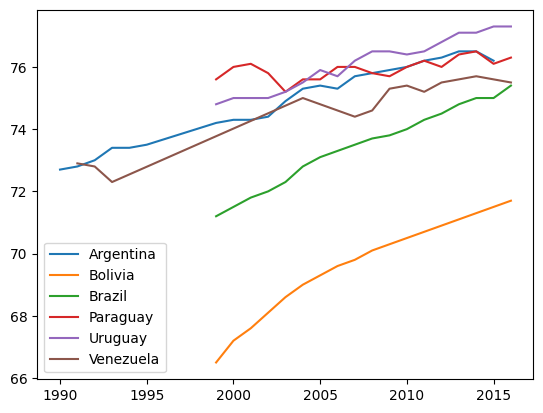

In [32]:
#análise de expectativa de vida	para os países do mercosul
# Geração do gráfico de expectativa de vida para os países do Mercosul
df = df_mercosul.dropna(subset=['life_expectancy'])

for country in df['country'].unique():
    dados = df[df['country'] == country]
    plt.plot(dados['year'], dados['life_expectancy'], label=country)
    

plt.legend()
plt.show()

De forma semelhante, a expectativa de vida possui comportamento semelhante a evolução do acesso ao saneamento básico

Com atenção a venezuela e a Bolívia.